# Duration-Conservatism Analysis — are the duration assumptions conservative?

**Status:** closes Chris's 2026-06-19 action item · diagnostic, no price change · **Built:** 2026-06-22

```text
 STAGE     Step 1: eventization — 15-min snapshots -> events with a DURATION
 QUESTION  Chris: "I'm comfortable being conservative, but I'm not sure our math
           suggests we're conservative ONLY on the long-duration stuff. Are we
           undercutting the short durations?"   (action item: prove duration is conservative)
 SOLUTION  this analysis — the DIRECTION (structural) + the bounded sensitivity (data)
```

Chris's worry, concretely: we assign each county event a single duration (first positive
snapshot → last + 15 min, bridging gaps up to tolerance). Does that **over-weight long
durations** while **undercutting short ones**?

## 1. The structural argument — why the direction is conservative

A county event's duration is the span over which **someone, somewhere in the county** was
out. Any single customer is out for a **subset** of that span. So:

```text
   county-event duration  ≥  any individual customer's outage duration
        ⇒  counting an event as "≥ T" OVER-counts how many customers truly had a ≥T outage
        ⇒  per-customer qualifying frequency is OVER-stated  =  CONSERVATIVE (over-price)
```

This is the duration side of **A011** (the synchronous-outage approximation). The
per-customer fundamentals bracket the magnitude at **~2–3×** over-statement for the realistic
core+periphery regime (worked Cases B/C). The *direction* is structural and threshold-independent;
the *amount* of cushion grows with duration (see the cell read's cushion LEVEL).

What about Chris's "1h + 2h break + 1h → false long event"? Our gap tolerance bridges at most
**3 missing 15-min snapshots (≤45 min)**, so a 2-hour break **always splits** — that specific
failure cannot happen by construction.

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
while not os.path.isdir("price_engine/catalogs") and os.getcwd()!="/": os.chdir("..")
CATS=["eagle-i-30min","eagle-i-45min","eagle-i-60min"]; TS=[2,4,8,12,24]
PCL="curated_outage_data/outputs/per_customer_rate/per_customer_lambda__{}.parquet"
OUT="notebooks/outputs/duration_conservatism_analysis"; os.makedirs(OUT, exist_ok=True)

# (2) gap-merge sensitivity: total qualifying events by T, by catalog (looser gap = more merging)
tot={c: pd.read_parquet(PCL.format(c), columns=["fips","T","n_events_qualifying"])
        .groupby("T")["n_events_qualifying"].sum() for c in CATS}
sens=pd.DataFrame(tot); sens.columns=["gap30","gap45","gap60"]
sens["pct_30_to_60"]=((sens.gap60-sens.gap30)/sens.gap30*100).round(1)
print(sens.round(0).to_string())

        gap30      gap45      gap60  pct_30_to_60
T                                                
2   6643590.0  6541663.0  6450160.0          -3.0
4   3422752.0  3482371.0  3541694.0           4.0
8   1449695.0  1515030.0  1579821.0           9.0
12   804647.0   846231.0   888089.0          10.0
24   269059.0   280410.0   292709.0           9.0


## 2. The eventization knob moves λ only a little — and in Chris's predicted direction

```text
 as the gap tolerance LOOSENS (30 → 60 min, the full reasonable range):
   short T (2h)  -> FEWER qualifying  (merging absorbs short events)   ← mildly anti-conservative
   long  T (8h+) -> MORE  qualifying  (merging builds long events)     ← more conservative
```

The whole 30→60 range moves λ by only **−3% (2h) to +10% (long T)**. So the duration/merge
choice is a **bounded ~10% lever**, not a heavy mis-weighting — a direct, quantified answer to
"are we heavily over-weighting long durations?": **no.**

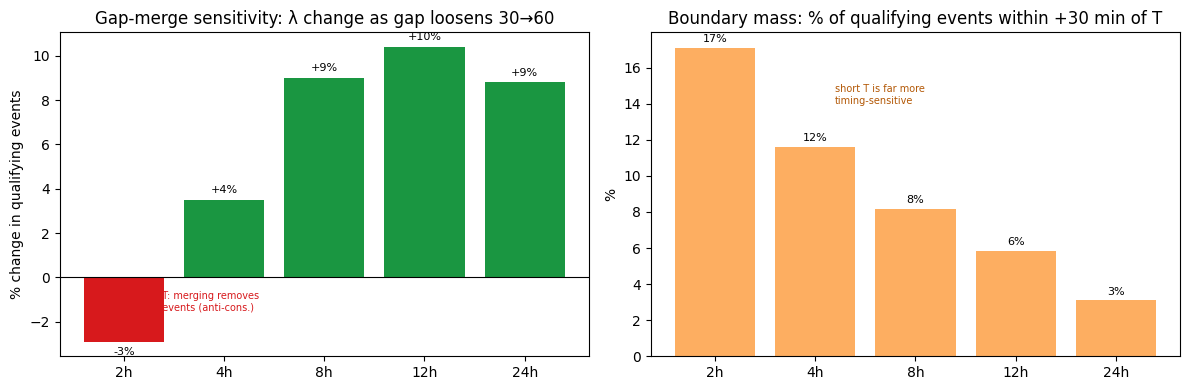

wrote: notebooks/outputs/duration_conservatism_analysis


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x=[str(t)+"h" for t in sens.index]
col=["#d7191c" if v<0 else "#1a9641" for v in sens.pct_30_to_60]
ax[0].bar(x, sens.pct_30_to_60, color=col); ax[0].axhline(0,color="k",lw=.8)
ax[0].set_title("Gap-merge sensitivity: λ change as gap loosens 30→60"); ax[0].set_ylabel("% change in qualifying events")
for i,v in enumerate(sens.pct_30_to_60): ax[0].text(i, v+(0.3 if v>=0 else -0.6), f"{v:+.0f}%", ha="center", fontsize=8)
ax[0].annotate("short T: merging removes\nshort events (anti-cons.)", xy=(0,-2.9), xytext=(0.1,-1.5), fontsize=7, color="#d7191c")

# (3) boundary mass: fraction of qualifying events barely clearing T (45-cat)
ev=pd.read_parquet("price_engine/catalogs/eagle-i-45min/data/events.parquet", columns=["duration_hours"])
bm=[((ev.duration_hours>=T)&(ev.duration_hours<T+0.5)).sum()/ (ev.duration_hours>=T).sum() for T in TS]
ax[1].bar(x, [b*100 for b in bm], color="#fdae61")
ax[1].set_title("Boundary mass: % of qualifying events within +30 min of T"); ax[1].set_ylabel("%")
for i,b in enumerate(bm): ax[1].text(i, b*100+0.3, f"{b*100:.0f}%", ha="center", fontsize=8)
ax[1].annotate("short T is far more\ntiming-sensitive", xy=(0,17), xytext=(1.2,14), fontsize=7, color="#b35806")
plt.tight_layout(); plt.savefig(OUT+"/duration_conservatism.png", dpi=110); plt.show()
sens.to_csv(OUT+"/gap_merge_sensitivity_by_T.csv")
pd.DataFrame({"T":TS,"boundary_mass_within_30min":bm}).to_csv(OUT+"/boundary_mass_by_T.csv", index=False)
print("wrote:", OUT)

## 3. Verdict by threshold

```text
 T    structural over-count   eventization knob (30→60)   boundary mass   net read
 ────────────────────────────────────────────────────────────────────────────────────────
 2h   conservative            −3%  (mildly ANTI-cons.)     17%            conservative but THIN
                                                                          + timing-sensitive → VERIFY, don't lead
 4h   conservative            +3.5%                        12%            conservative, modest margin
 8h   conservative (strong)   +9%  (more cons. as loosened) 8%            ROBUSTLY conservative
 12h  conservative (strong)   +10%                          6%            ROBUSTLY conservative
 24h  conservative (strong)   +9%                           3%            ROBUSTLY conservative
```

**Answer to Chris.** Yes, the duration assumptions are conservative — the *direction* is
structural (county duration ≥ individual duration → over-count) at every T. But he was right
that the conservatism is **not uniform**: it is strong and robust at 8h/12h+, and **thin +
timing-sensitive at 2h/4h**, where the eventization knob is even mildly anti-conservative.
That is exactly why we **lead with 8h/12h** and the cell read flags short-T cells as
*runs close — verify*. This maps 1:1 to the cushion LEVEL in
[`cell_read_fundamentals.md`](../docs/methodology/02_per_customer/cell_read_fundamentals.md).

## 4. The ceiling — what would turn this from "direction" into "proof of magnitude"

The structural argument proves the **direction** (conservative) and bounds the **eventization
sensitivity** (~10%). It does **not** measure the exact short-T magnitude, because EAGLE-I has
no per-customer outage durations — we cannot directly count how many customers were truly out
≥ 2h. That needs **per-outage durations** (the PowerOutage.US trial / A011 resolution path).
Until then: ship conservative, lead long-T, flag short-T. Honest, not overclaimed.